# Temel Bileşen Analizi

Bu ısınma alıştırması, **Temel Bileşen Analizi**'nin nasıl çalıştığına dair sezgisel bir fikir edinmenize yardımcı olacaktır. 

## (1) Veri Oluşturma

**100 gözlem** ve **birbiriyle ilişkili (korelasyonlu) 2 özellik** içeren bir veri seti istiyoruz.

👇 Verinizi oluşturmak için aşağıdaki hücreyi çalıştırın  
💡 İki özellik arasındaki (yüksek) korelasyona dikkat edin.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 100 gözlem ve 2 ilişkili özellik içeren bir veri kümesi oluşturun.
seed = np.random.RandomState(42)
feature_1 = seed.normal(5, 1, 100)
feature_2 = .7 * feature_1 + seed.normal(0, .5, 100)
X = np.array([feature_1, feature_2]).T
X = pd.DataFrame(X)

X.corr().round(3)

,0,1
0,1.00,0.77
1,0.77,1.00


❓ İki özelliğinizi birbirine göre dağılım grafiği çizin.

<function matplotlib.pyplot.show(close=None, block=None)>

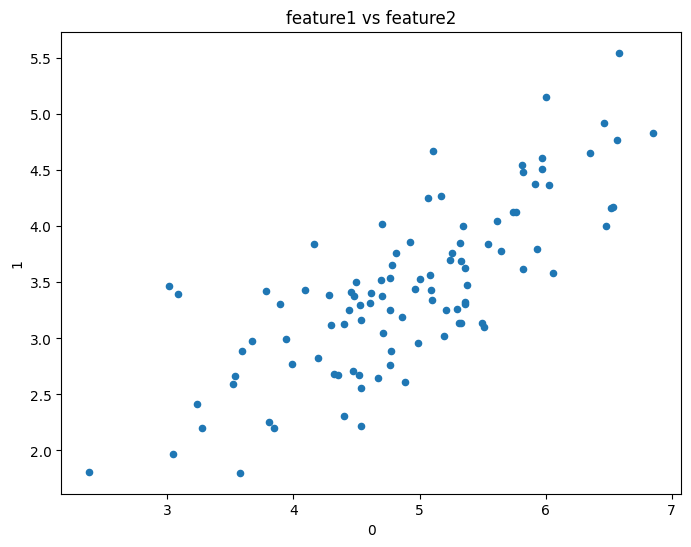

In [4]:
X.plot.scatter(x=0,y=1,figsize=(8,6))
plt.title("feature1 vs feature2")
plt.show

☝️ Özellikler arasındaki **pozitif korelasyonu** tespit edebilirsiniz.

Gözlemlerimiz tek bir çizgi boyunca sıkışmış durumda; aralarındaki farkları ayırt etmek kolay değil.

💡 PCA, bu korelasyonu ortadan kaldıran yönleri (diğer adıyla **“principal components” – temel bileşenler**) bulmamıza yardımcı olacaktır.

## (2) Temel Bileşenler

👉 `sklearn`'den `PCA`'yı içe aktarın ve `n_components=2` ile bir model oluşturun

❓Bunu `X`'inize uyarlayın ve `pca`'ya atayın

In [5]:
from sklearn.decomposition import PCA
pca= PCA(n_components=2).fit(X)

Eğitilmiş `PCA` nesnesinin üç özniteliğine odaklanalım:

* `pca.components_`: Varyansın en iyi şekilde açıklandığı yönleri gösteren özvektörler kümesi; yani **maksimum varyans yönleri** (konvansiyon gereği birim uzunluğa normalize edilmişlerdir).

* `pca.explained_variance_`:  
  $Var(\text{Temel Bileşen})$, her bir temel bileşenin açıkladığı varyans (kovaryans matrisi  
  $ \Sigma = \frac{1}{n - 1} X^T X $’in özdeğerleri ile verilir).

* `pca.explained_variance_ratio_`:  
  $ \frac{Var(\text{Temel Bileşen})}{\text{Toplam Varyans}}$, her bir temel bileşenin toplam varyansın ne kadarını açıkladığını gösterir.

In [6]:
# Her bir ana bileşenin vektör koordinatları
pca.components_

array([[ 0.79286897,  0.60939216],
       [-0.60939216,  0.79286897]])

In [7]:
# Her bir ana bileşen için açıklanan varyans
# Önem sırasına göre azalan şekilde sıralanmıştır
pca.explained_variance_

array([1.2231014 , 0.15046893])

In [8]:
# Her bir ana bileşen için açıklanan varyans oranı
# Önem sırasına göre azalan şekilde sıralanmıştır

# Her bir ana bileşen için açıklanan varyans
# verilerin toplam varyansına bölünmüştür
pca.explained_variance_ratio_

array([0.89045415, 0.10954585])

👇 Aşağıdaki hücreyi çalıştırarak iki ana bileşeninizi görselleştirin.

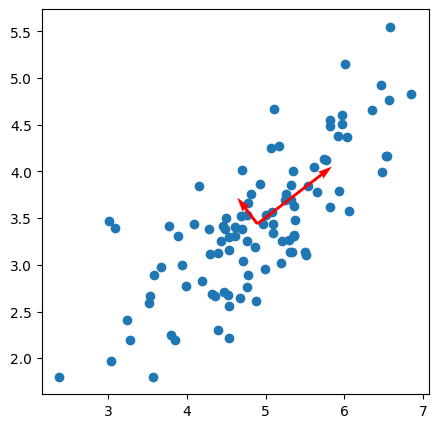

In [9]:
plt.figure(figsize=(5,5))

plt.scatter(X[0], X[1])

for (length, vector) in zip(pca.explained_variance_, pca.components_):
    v = vector * np.sqrt(length) # Aynı “birimleri” karşılaştırmak için uzunluklarının karekökü
    plt.quiver(*X.mean(axis=0), *v, units='xy', scale=1, color='r')

💡 Vektörün uzunluğu, veri kümesinin bu eksene yansıtıldığında standart sapmasının bir ölçüsüdür!

💡 Daha sonra bu yönleri (bu “ana bileşenleri”) kullanarak gözlemlerimizin davranışlarının çoğunu “açıklayabiliriz” - gözlemler arasındaki farkların çoğu bu eksenler boyunca gerçekleşir. 

## (3) PCA uygulayın

Bu bileşenleri kullanarak veri setimizdeki her bir örneği, maksimum varyans yönlerine projekte edebiliriz.

❓ ***Sorular*** ❓

1. `pca` nesnesinin `transform` metodunu `X` üzerinde kullanın ve sonucu `X_transformed` değişkenine kaydedin.  
2. `X_transformed` içindeki projekte edilmiş özellikleri birbirlerine karşı grafiğe dökün.  
3. `X_transformed` içindeki dönüştürülmüş özellikler arasındaki korelasyonu hesaplayın.

In [10]:
X_transformed = pca.transform(X)

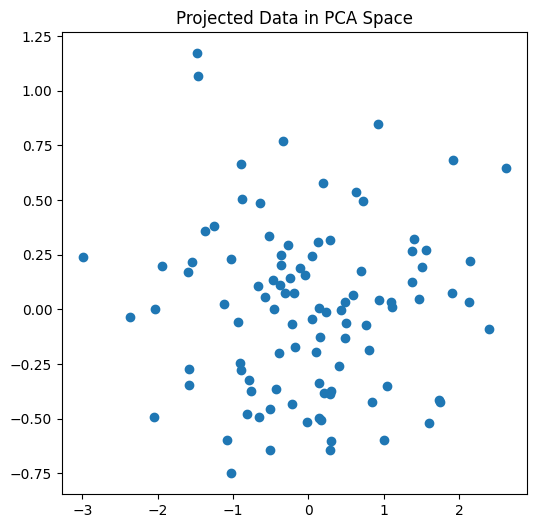

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(X_transformed[:, 0], X_transformed[:, 1])
plt.title("Projected Data in PCA Space")
plt.show()

In [13]:
pd.DataFrame(X_transformed).corr().round(3)

,0,1
0,1.0,-0.0
1,-0.0,1.0


☝️ Dönüştürülmüş özellikleriniz arasında hiçbir korelasyon yoktur.  

Bu, gözlemler arasında davranışları incelemek daha kolay hale getirir, çünkü artık tek bir çizgi üzerinde toplanmış değildirler.

🏁 **Not defterinizi PUSH etmeyi unutmayın.**  

Günün görevlerini yerine getirin ve zamanınız olursa buraya geri dönün 😉

## (Opsiyonel) Scaling'in küçük bir yardımıyla

`PCA` ile elde edilen **projeksiyonların**, aslında başlangıçtaki `X` matrisi ile *transpoze edilmiş* bileşenlerin (yani `pca.components_` ile elde edilen özvektörlerin) noktasal çarpımından ibaret olduğunu unutmayın.

👉 Noktasal çarpımı kullanarak projekte edilmiş değerleri **manuel olarak** hesaplayın:  
$X \cdot PC^T$

❓ `np.allclose` kullanarak, elde ettiğiniz `X_transformed` ile hesapladığınız  $X \cdot PC^T$ sonucunun **aynı olup olmadığını** kontrol edin.

In [18]:
np.dot(X, pca.components_.T)

array([[ 6.2716743 , -0.86003441],
       [ 5.8004429 , -0.43115836],
       [ 6.78261318, -0.44300707],
       [ 7.71001547, -0.67279805],
       [ 5.76253746, -0.32312445],
       [ 5.93481331, -0.09900643],
       [ 8.5976916 ,  0.38994601],
       [ 7.08625383, -0.24444681],
       [ 5.6031945 , -0.1442857 ],
       [ 6.73615531, -0.33093885],
       [ 4.94746364, -1.00738402],
       [ 5.5212076 , -0.25710222],
       [ 6.41062861, -0.26120091],
       [ 4.51462048,  0.80864632],
       [ 3.93516595, -0.2543702 ],
       [ 5.50341982, -0.12179626],
       [ 4.85155054, -0.23059866],
       [ 6.12433263, -0.75231366],
       [ 5.33814698,  0.23051684],
       [ 4.6041039 ,  0.10297934],
       [ 8.12551755, -0.03803473],
       [ 5.54480916, -0.62015335],
       [ 6.60699014,  0.28052419],
       [ 3.93267898, -0.75017817],
       [ 5.61218648, -0.00966337],
       [ 6.89990445,  0.59042034],
       [ 4.39183324, -0.60200666],
       [ 6.38281119, -0.51685126],
       [ 5.39513583,

Eşit değil 😱  

`sklearn`'in `PCA`'sı indirgemeyi uyguladığında, bunu *merkezlenmiş* ancak *ölçeklenmemiş* bir `X` üzerinde yapar.

Bu, `PCA().transform(X)`'in aslında `np.dot(X - X.mean(axis=0), PC)` ile eşdeğer olduğu anlamına gelir.

In [19]:
np.allclose(X_transformed, np.dot(X - X.mean(axis=0), PC))

True

Bu nedenle, `PCA` kullanırken, verilerinizi öncelikle ölçeklendirmenizi, daha doğrusu standartlaştırmanızı ve böylece verilerin merkezlenmesini öneririz.

Bu şekilde, `PCA.transform()` kullanmak veya ana bileşenlerle nokta çarpımı yapmak eşdeğer olacaktır.